# Color Spaces in OpenCV

OpenCV loads images as **BGR** (not RGB). Different color spaces separate **luminance** from **chrominance** for easier processing.

**Image sources:** `skimage.data.astronaut`, `skimage.data.coffee`.

---

## 1. BGR vs RGB

| Space | Channel order | Used by |
|-------|---------------|---------|
| BGR | Blue, Green, Red | OpenCV default |
| RGB | Red, Green, Blue | Matplotlib, most ML frameworks |

Always convert before displaying: `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)`.

---

## 2. HSV — Hue, Saturation, Value

| Channel | Meaning | Range (OpenCV) |
|---------|---------|----------------|
| **H** | color tone (angle on color wheel) | 0–179 (8-bit scaled) |
| **S** | color purity / intensity | 0–255 |
| **V** | brightness | 0–255 |

**Why HSV?** Easy to select colors by hue range; lighting changes mostly affect **V**, not **H**.

---

## 3. LAB — perceptual lightness

| Channel | Meaning |
|---------|---------|
| **L** | lightness (perceptual) |
| **a** | green ↔ red |
| **b** | blue ↔ yellow |

Good for histogram equalization on **L** only — brightness changes without shifting hue.

---

## 4. YCrCb — video / JPEG

Luminance **Y** + chroma **Cr**, **Cb**. Common in compression pipelines.


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from urllib.request import urlretrieve
import skimage.data as skid

plt.rcParams.update({
    "figure.figsize": (12, 4),
    "figure.dpi": 100,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

NOTEBOOK_DIR = Path.cwd()
IMAGES_CACHE = NOTEBOOK_DIR.parent / "Images"
IMAGES_CACHE.mkdir(exist_ok=True)

ECE533_URLS = {
    "peppers": "https://homepages.cae.wisc.edu/~ece533/images/peppers.png",
    "boat": "https://homepages.cae.wisc.edu/~ece533/images/boat.png",
    "baboon": "https://homepages.cae.wisc.edu/~ece533/images/baboon.png",
}

SKIMAGE_FALLBACK = {
    "peppers": skid.astronaut,
    "boat": skid.camera,
    "baboon": skid.chelsea,
}


def load_sample_image(name):
    """Load from skimage.data or download Wisconsin ECE533 image (cached locally)."""
    skimg_map = {
        "camera": skid.camera,
        "coins": skid.coins,
        "astronaut": skid.astronaut,
        "coffee": skid.coffee,
        "chelsea": skid.chelsea,
        "page": skid.page,
    }
    if name in skimg_map:
        img = skimg_map[name]()
        if img.ndim == 2:
            return img.astype(np.uint8)
        return cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    cache_path = IMAGES_CACHE / f"{name}.png"
    if cache_path.exists():
        img = cv2.imread(str(cache_path), cv2.IMREAD_UNCHANGED)
        if img is not None:
            return img

    url = ECE533_URLS.get(name)
    if url:
        try:
            print(f"Downloading {name} from ECE533 ...")
            urlretrieve(url, cache_path)
            img = cv2.imread(str(cache_path), cv2.IMREAD_UNCHANGED)
            if img is not None:
                return img
        except Exception as exc:
            print(f"Download failed ({exc}); using skimage fallback.")

    fallback = SKIMAGE_FALLBACK.get(name, skid.camera)
    img = fallback()
    if img.ndim == 2:
        return img.astype(np.uint8)
    return cv2.cvtColor(img, cv2.COLOR_RGB2BGR)


def to_rgb(bgr):
    if bgr.ndim == 2:
        return bgr
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


def show_gray(ax, img, title=""):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")


def show_rgb(ax, img_bgr, title=""):
    ax.imshow(to_rgb(img_bgr))
    ax.set_title(title)
    ax.axis("off")


def side_by_side(images, titles, rgb_flags=None, cols=4):
    """Plot a row/grid of images. images: list of arrays; rgb_flags: True for BGR color."""
    n = len(images)
    cols = min(cols, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3.2 * cols, 3.2 * rows))
    axes = np.atleast_1d(axes).ravel()
    for i, (img, title) in enumerate(zip(images, titles)):
        is_rgb = rgb_flags[i] if rgb_flags else (img.ndim == 3)
        if is_rgb:
            show_rgb(axes[i], img, title)
        else:
            show_gray(axes[i], img, title)
    for j in range(n, len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.show()


def add_salt_pepper(gray, amount=0.05):
    """Inject salt-and-pepper noise into a uint8 grayscale image."""
    out = gray.copy()
    n = int(amount * gray.size)
    rng = np.random.default_rng(42)
    coords = (rng.integers(0, gray.shape[0], n), rng.integers(0, gray.shape[1], n))
    out[coords] = 255
    coords = (rng.integers(0, gray.shape[0], n), rng.integers(0, gray.shape[1], n))
    out[coords] = 0
    return out


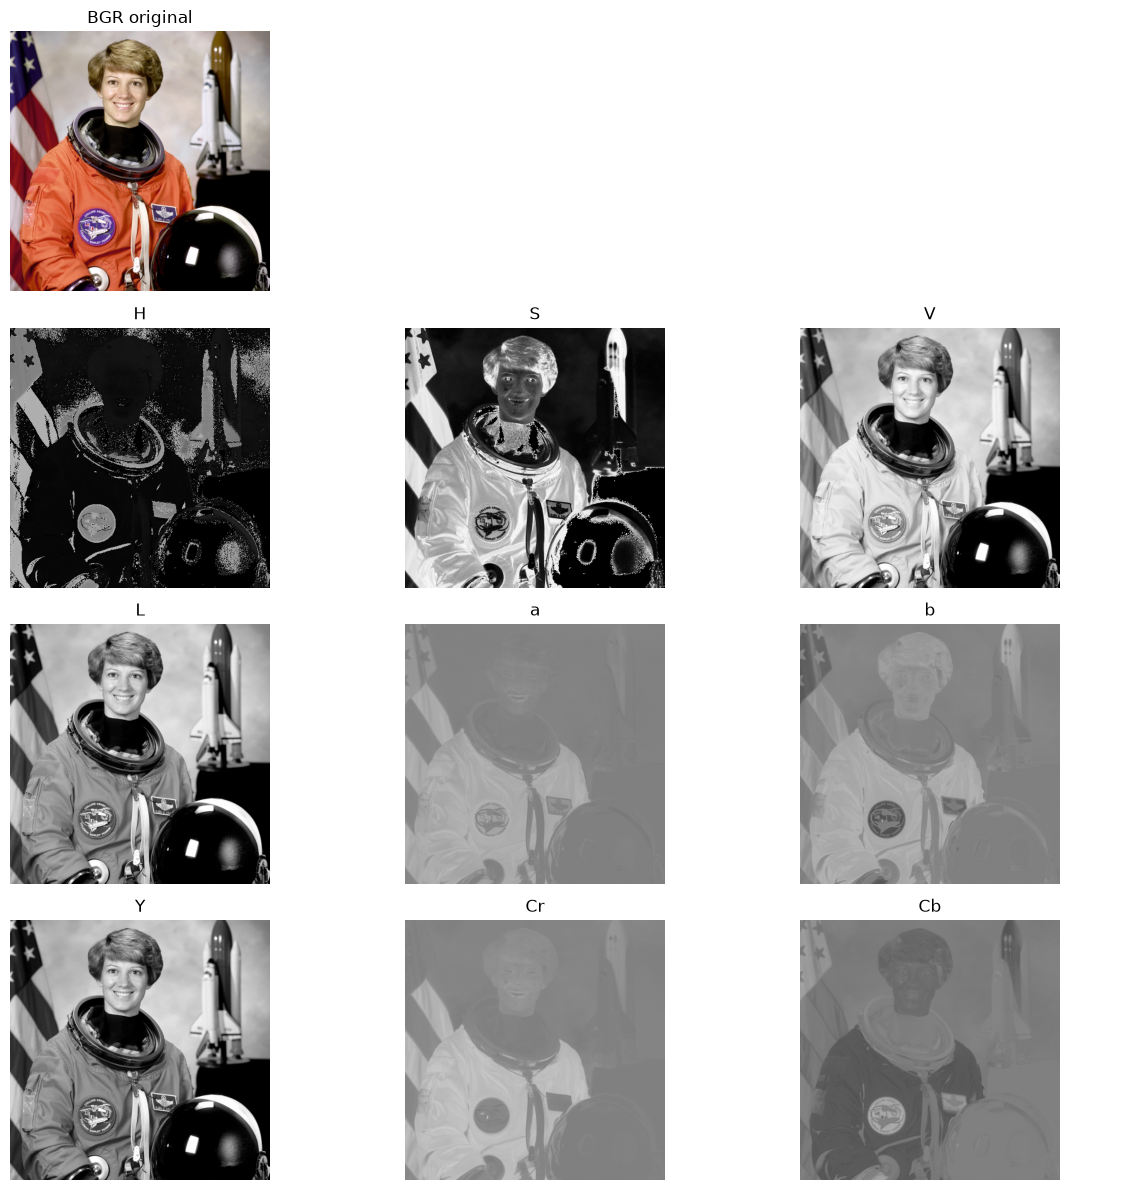

In [23]:
astronaut = load_sample_image("astronaut")
coffee = load_sample_image("coffee")

hsv = cv2.cvtColor(astronaut, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)
lab = cv2.cvtColor(astronaut, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)
ycrcb = cv2.cvtColor(astronaut, cv2.COLOR_BGR2YCrCb)
y, cr, cb = cv2.split(ycrcb)

fig, axes = plt.subplots(4, 3, figsize=(12, 12))
show_rgb(axes[0, 0], astronaut, "BGR original")
for i, (ch, name) in enumerate(zip([h, s, v], ["H", "S", "V"])):
    show_gray(axes[1, i], ch, name)
for i, (ch, name) in enumerate(zip([l, a, b], ["L", "a", "b"])):
    show_gray(axes[2, i], ch, name)
for i, (ch, name) in enumerate(zip([y, cr, cb], ["Y", "Cr", "Cb"])):
    show_gray(axes[3, i], ch, name)
for j in range(1, 3):
    axes[0, j].axis("off")
plt.tight_layout()
plt.show()


## 5. HSV color selection (masking)

Pick a hue range to isolate objects by color — useful for segmentation.


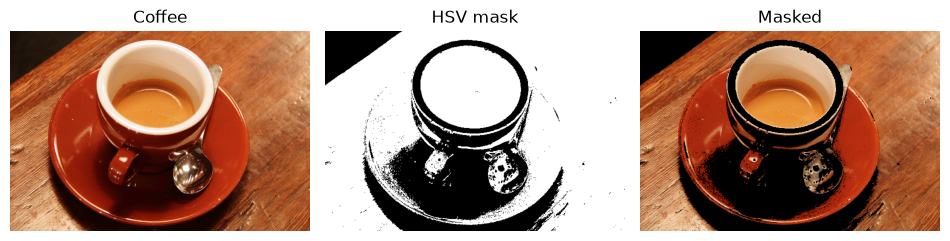

In [24]:
# Coffee cup — orange/brown hues (approximate)
hsv_c = cv2.cvtColor(coffee, cv2.COLOR_BGR2HSV)
lower = np.array([5, 50, 100])
upper = np.array([20, 255, 255])
mask = cv2.inRange(hsv_c, lower, upper)
masked = cv2.bitwise_and(coffee, coffee, mask=mask)
side_by_side([coffee, mask, masked], ["Coffee", "HSV mask", "Masked"], rgb_flags=[True, False, True])


## 6. Histogram equalization (global)

**Problem:** many images use only part of the 0–255 intensity range → low **global contrast** (washed out or too dark).

**Idea:** remap intensities so the output histogram is approximately **uniform** — more pixels at every brightness level.

For grayscale with $L$ levels, cumulative distribution function (CDF):

$$
\operatorname{CDF}(i)=\sum_{j=0}^{i}p(j),
\qquad
p(j)=\frac{\#\{ \text{pixels with intensity } j \}}{\text{total number of pixels}}
$$

$$
s=\operatorname{round}\left(
\frac{\operatorname{CDF}(r)-\operatorname{CDF}_{\min}}
{1-\operatorname{CDF}_{\min}}
\,(L-1)
\right)
$$

| Property | Detail |
|----------|--------|
| OpenCV | `cv2.equalizeHist(gray)` — **grayscale only** |
| Scope | Uses **entire image** statistics (global) |
| Effect | Spreads histogram; can **over-boost noise** and blow highlights in one shot |
| Color | Do **not** equalize BGR channels separately (shifts colors) — equalize **V** (HSV) or **L** (LAB) instead |

**Demo below:** grayscale `equalizeHist`, then the same global HE applied to **L** (LAB) and **V** (HSV) on a low-contrast color image.

**When it helps:** flat lighting, foggy/low-contrast grayscale, V channel in HSV.


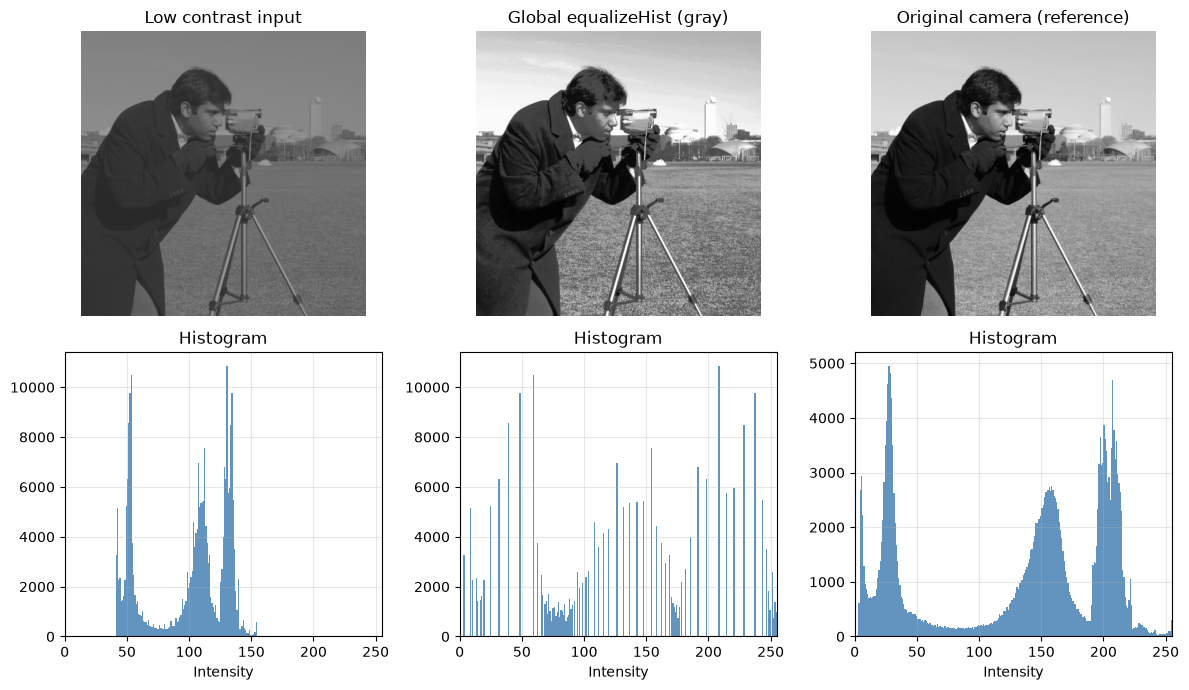

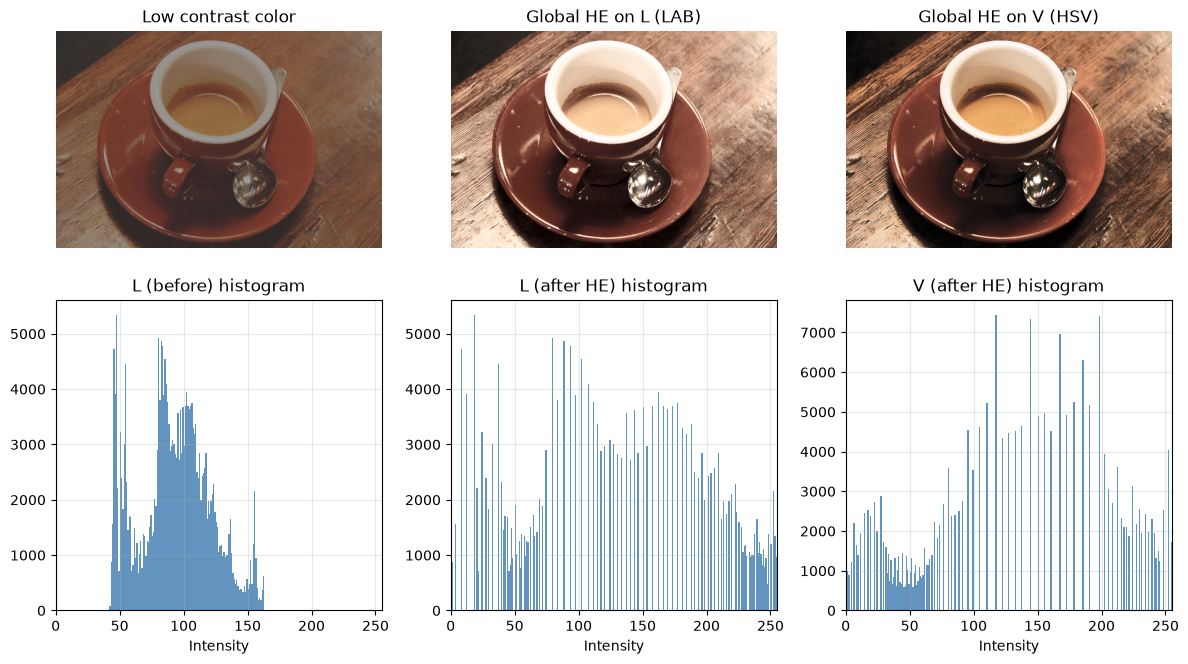

Grayscale: equalizeHist spreads the full 0–255 range (noise amplified too).
Color: equalize only L (LAB) or V (HSV) — hue/saturation stay intact; never HE each BGR channel separately.


In [25]:
def plot_image_and_hist(ax_img, ax_hist, img, title, cmap="gray", is_bgr=False):
    if is_bgr:
        ax_img.imshow(to_rgb(img))
    else:
        ax_img.imshow(img, cmap=cmap, vmin=0, vmax=255)
    ax_img.set_title(title)
    ax_img.axis("off")
    ax_hist.hist(img.ravel() if not is_bgr else cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).ravel(),
                 bins=256, range=(0, 256), color="steelblue", alpha=0.85)
    ax_hist.set_xlim(0, 255)
    ax_hist.set_title("Histogram")
    ax_hist.set_xlabel("Intensity")


def plot_color_and_channel_hist(ax_img, ax_hist, bgr, channel, title, channel_label):
    ax_img.imshow(to_rgb(bgr))
    ax_img.set_title(title)
    ax_img.axis("off")
    ax_hist.hist(channel.ravel(), bins=256, range=(0, 256), color="steelblue", alpha=0.85)
    ax_hist.set_xlim(0, 255)
    ax_hist.set_title(f"{channel_label} histogram")
    ax_hist.set_xlabel("Intensity")


def equalize_lab_l(bgr):
    lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    l_eq = cv2.equalizeHist(l)
    out = cv2.cvtColor(cv2.merge([l_eq, a, b]), cv2.COLOR_LAB2BGR)
    return out, l, l_eq


def equalize_hsv_v(bgr):
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    v_eq = cv2.equalizeHist(v)
    out = cv2.cvtColor(cv2.merge([h, s, v_eq]), cv2.COLOR_HSV2BGR)
    return out, v, v_eq


# --- Grayscale global HE ---
camera = load_sample_image("camera")
low_contrast = np.clip(camera.astype(np.float32) * 0.45 + 40, 0, 255).astype(np.uint8)
global_eq = cv2.equalizeHist(low_contrast)

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
plot_image_and_hist(axes[0, 0], axes[1, 0], low_contrast, "Low contrast input")
plot_image_and_hist(axes[0, 1], axes[1, 1], global_eq, "Global equalizeHist (gray)")
plot_image_and_hist(axes[0, 2], axes[1, 2], camera, "Original camera (reference)")
plt.tight_layout()
plt.show()

# --- Color: equalize luminance channel only (LAB-L or HSV-V) ---
coffee = load_sample_image("coffee")
low_contrast_color = np.clip(coffee.astype(np.float32) * 0.45 + 40, 0, 255).astype(np.uint8)

lab_eq, l_before, l_after = equalize_lab_l(low_contrast_color)
hsv_eq, v_before, v_after = equalize_hsv_v(low_contrast_color)

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
plot_color_and_channel_hist(
    axes[0, 0], axes[1, 0], low_contrast_color, l_before,
    "Low contrast color", "L (before)",
)
plot_color_and_channel_hist(
    axes[0, 1], axes[1, 1], lab_eq, l_after,
    "Global HE on L (LAB)", "L (after HE)",
)
plot_color_and_channel_hist(
    axes[0, 2], axes[1, 2], hsv_eq, v_after,
    "Global HE on V (HSV)", "V (after HE)",
)
plt.tight_layout()
plt.show()

print("Grayscale: equalizeHist spreads the full 0–255 range (noise amplified too).")
print("Color: equalize only L (LAB) or V (HSV) — hue/saturation stay intact; never HE each BGR channel separately.")

## 7. CLAHE — Contrast Limited Adaptive Histogram Equalization

**Problem with global HE:** one histogram for the whole image. A bright sky and dark foreground share the same remap → **local** detail can still be lost, and noise gets boosted everywhere.

**CLAHE idea:** split the image into small **tiles** (e.g. 8×8). Run histogram equalization **locally** in each tile, then **interpolate** between tiles for smooth transitions.

| Parameter | Role |
|-----------|------|
| `clipLimit` | caps histogram peak before equalization — limits noise amplification (**contrast limiting**) |
| `tileGridSize` | `(cols, rows)` of tiles — smaller tiles → more local, can look blocky |

OpenCV: `cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))` then `.apply(gray)`.

**Color images:** apply CLAHE to **L** (LAB) or **V** (HSV), merge back — same as global HE, never on B/G/R separately.

| Method | Scope | Noise | Local detail |
|--------|-------|-------|--------------|
| Global HE | whole image | often high | moderate |
| CLAHE | per tile + clip | controlled | strong |

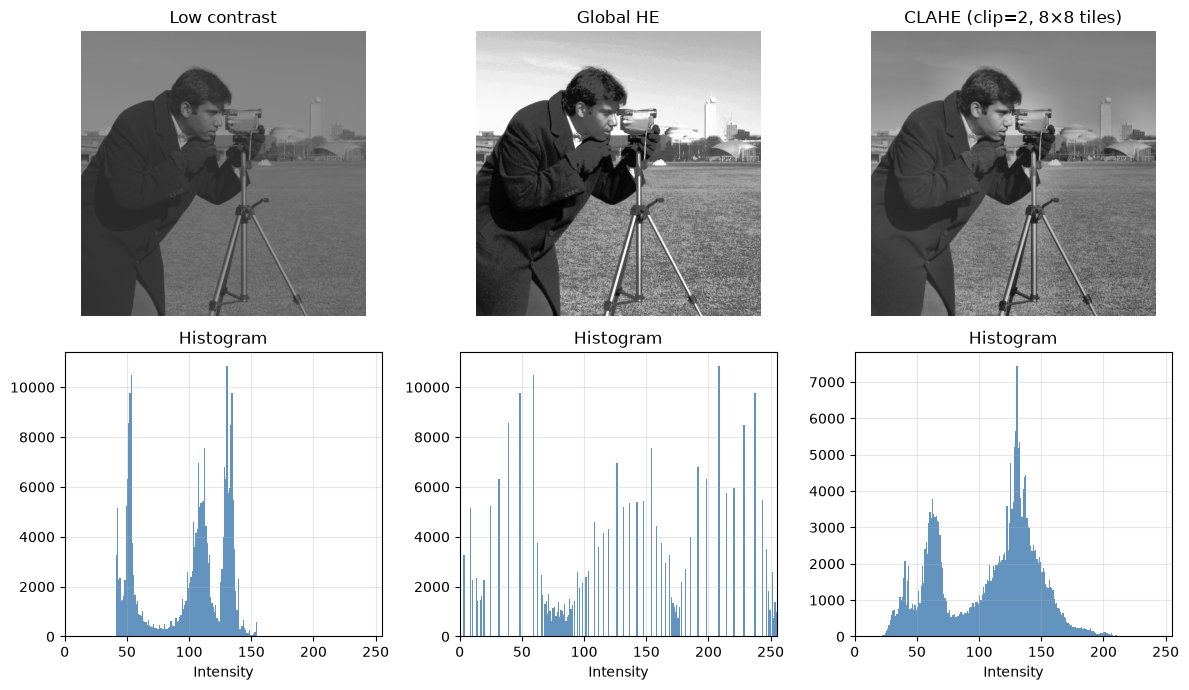

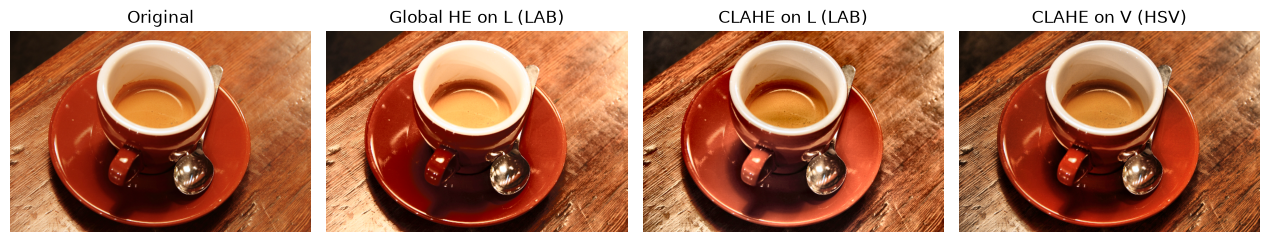

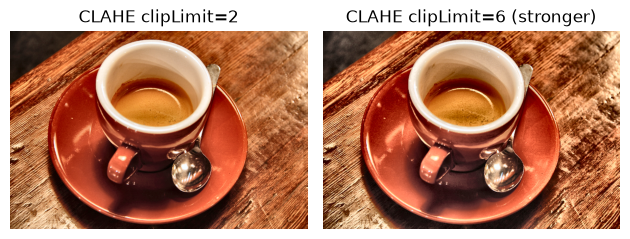

In [26]:
# Grayscale: global HE vs CLAHE on the same low-contrast image
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
clahe_gray = clahe.apply(low_contrast)

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
plot_image_and_hist(axes[0, 0], axes[1, 0], low_contrast, "Low contrast")
plot_image_and_hist(axes[0, 1], axes[1, 1], global_eq, "Global HE")
plot_image_and_hist(axes[0, 2], axes[1, 2], clahe_gray, "CLAHE (clip=2, 8×8 tiles)")
plt.tight_layout()
plt.show()

# Color: CLAHE on LAB L channel (preserves hue)
coffee = load_sample_image("coffee")
lab_c = cv2.cvtColor(coffee, cv2.COLOR_BGR2LAB)
l_c, a_c, b_c = cv2.split(lab_c)
l_global = cv2.equalizeHist(l_c)
l_clahe = clahe.apply(l_c)
enhanced_global = cv2.cvtColor(cv2.merge([l_global, a_c, b_c]), cv2.COLOR_LAB2BGR)
enhanced_clahe = cv2.cvtColor(cv2.merge([l_clahe, a_c, b_c]), cv2.COLOR_LAB2BGR)

# CLAHE on HSV V channel (alternative)
hsv_c = cv2.cvtColor(coffee, cv2.COLOR_BGR2HSV)
h_c, s_c, v_c = cv2.split(hsv_c)
v_clahe = clahe.apply(v_c)
enhanced_v = cv2.cvtColor(cv2.merge([h_c, s_c, v_clahe]), cv2.COLOR_HSV2BGR)

side_by_side(
    [coffee, enhanced_global, enhanced_clahe, enhanced_v],
    ["Original", "Global HE on L (LAB)", "CLAHE on L (LAB)", "CLAHE on V (HSV)"],
    rgb_flags=[True, True, True, True],
    cols=4,
)

# Higher clipLimit → stronger contrast (more noise risk)
clahe_strong = cv2.createCLAHE(clipLimit=6.0, tileGridSize=(8, 8))
l_strong = clahe_strong.apply(l_c)
enhanced_strong = cv2.cvtColor(cv2.merge([l_strong, a_c, b_c]), cv2.COLOR_LAB2BGR)
side_by_side(
    [enhanced_clahe, enhanced_strong],
    ["CLAHE clipLimit=2", "CLAHE clipLimit=6 (stronger)"],
    rgb_flags=[True, True],
)


## 8. Summary

| Space | Separates | Typical use |
|-------|-----------|-------------|
| BGR/RGB | device channels | I/O, display |
| HSV | hue vs brightness | color picking, segmentation, CLAHE on **V** |
| LAB | perceptual L vs color | CLAHE / HE on **L** without hue shift |
| YCrCb | luma vs chroma | video, JPEG |

| Enhancement | OpenCV | Best on | Limitation |
|-------------|--------|---------|------------|
| **Global histogram equalization** | `cv2.equalizeHist` | grayscale, V or L channel | whole-image stats; noisy |
| **CLAHE** | `cv2.createCLAHE` → `.apply` | grayscale, L or V | tune `clipLimit` and tile size |

**Rule of thumb:** for color, always equalize a **single luminance channel** (L or V), never R/G/B separately.
